<a href="https://colab.research.google.com/github/Faiz-Nadeem/Version-0.0-SNN-Model/blob/main/SNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

!pip install snntorch --quiet

import os
import zipfile
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from PIL import Image
from collections import Counter
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import snntorch as snn
from snntorch import surrogate, spikegen
import snntorch.functional as SF

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.6/133.6 kB 5.5 MB/s eta 0:00:00
Using device: cuda


In [ ]:
#2
DRIVE_ROOT = "/content/drive/MyDrive/snn_project"
os.makedirs(DRIVE_ROOT, exist_ok=True)

RAW_ZIP_PATH = f"{DRIVE_ROOT}/MILK10k_Training_Input.zip"
RAW_LABELS_PATH = f"{DRIVE_ROOT}/MILK10k_Training_GroundTruth.csv"
RAW_METADATA_PATH = f"{DRIVE_ROOT}/MILK10k_Training_Metadata.csv"

EXTRACT_DIR = "/content/milk10k_images"

SPLITS_DIR = f"{DRIVE_ROOT}/splits"
CHECKPOINT_DIR = f"{DRIVE_ROOT}/checkpoints"

os.makedirs(SPLITS_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

for path in [RAW_ZIP_PATH, RAW_LABELS_PATH, RAW_METADATA_PATH]:
    if not os.path.exists(path):
        print(f"MISSING: {path}")
        print("Upload this file to your Drive folder before continuing:", DRIVE_ROOT)
    else:
        print(f"Found: {path}")

Found: /content/drive/MyDrive/snn_project/MILK10k_Training_Input.zip
Found: /content/drive/MyDrive/snn_project/MILK10k_Training_GroundTruth.csv
Found: /content/drive/MyDrive/snn_project/MILK10k_Training_Metadata.csv


In [ ]:
#3
inner_folder = os.path.join(
    EXTRACT_DIR,
    "MILK10k_Training_Input"
)

if not os.path.exists(inner_folder):

    print("Extracting images...")

    os.makedirs(EXTRACT_DIR, exist_ok=True)

    with zipfile.ZipFile(RAW_ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)

    print("Extraction done.")

else:
    print("Images already extracted, skipping.")

Images already extracted, skipping.


In [ ]:
# Cell 4 — Build and save clean splits

from sklearn.model_selection import train_test_split

SPLITS_DIR_CLEAN = f"{DRIVE_ROOT}/splits_clean"
os.makedirs(SPLITS_DIR_CLEAN, exist_ok=True)

label_to_idx = {'BCC': 0, 'NV': 1, 'BKL': 2, 'SCCKA': 3, 'MEL': 4, 'AKIEC': 5}
idx_to_label = {v: k for k, v in label_to_idx.items()}
keep_classes = list(label_to_idx.keys())

meta_df = pd.read_csv(RAW_METADATA_PATH)
labels_df = pd.read_csv(RAW_LABELS_PATH)

derm_df = meta_df[meta_df['image_type'] == 'dermoscopic'].copy()
derm_full = derm_df.merge(labels_df, on='lesion_id', how='left')

def build_path(row):
    return f"{EXTRACT_DIR}/MILK10k_Training_Input/{row['lesion_id']}/{row['isic_id']}.jpg"

derm_full['filepath'] = derm_full.apply(build_path, axis=1)

mask = derm_full[keep_classes].sum(axis=1) == 1
filtered_df = derm_full[mask].copy()

def get_label(row):
    for c in keep_classes:
        if row[c] == 1:
            return c
    return None

filtered_df['label'] = filtered_df.apply(get_label, axis=1)

train_df, temp_df = train_test_split(
    filtered_df,
    test_size=0.30,
    stratify=filtered_df['label'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label'],
    random_state=42
)

train_split_path = f"{SPLITS_DIR_CLEAN}/train_split.csv"
val_split_path = f"{SPLITS_DIR_CLEAN}/val_split.csv"
test_split_path = f"{SPLITS_DIR_CLEAN}/test_split.csv"

train_df.to_csv(train_split_path, index=False)
val_df.to_csv(val_split_path, index=False)
test_df.to_csv(test_split_path, index=False)

print("Clean splits created and saved.")
print(f"\nTrain: {len(train_df)}")
print(f"Val:   {len(val_df)}")
print(f"Test:  {len(test_df)}")
print(f"Total: {len(train_df) + len(val_df) + len(test_df)}")

print("\nTraining distribution:")
print(train_df['label'].value_counts().reindex(keep_classes))

print("\nValidation distribution:")
print(val_df['label'].value_counts().reindex(keep_classes))

print("\nTest distribution:")
print(test_df['label'].value_counts().reindex(keep_classes))

print(f"\nSaved in: {SPLITS_DIR_CLEAN}")

Clean splits created and saved.

Train: 3526
Val:   756
Test:  756
Total: 5038

Training distribution:
label
BCC      1765
NV        522
BKL       381
SCCKA     331
MEL       315
AKIEC     212
Name: count, dtype: int64

Validation distribution:
label
BCC      379
NV       112
BKL       81
SCCKA     71
MEL       68
AKIEC     45
Name: count, dtype: int64

Test distribution:
label
BCC      378
NV       112
BKL       82
SCCKA     71
MEL       67
AKIEC     46
Name: count, dtype: int64

Saved in: /content/drive/MyDrive/snn_project/splits_clean


In [ ]:
#5
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

label_to_idx = {
    'BCC': 0, 'NV': 1, 'BKL': 2,
    'SCCKA': 3, 'MEL': 4, 'AKIEC': 5
}
idx_to_label = {v: k for k, v in label_to_idx.items()}

class MILK10kDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['filepath']).convert('RGB')
        label = label_to_idx[row['label']]
        if self.transform:
            image = self.transform(image)
        return image, label

train_dataset = MILK10kDataset(train_df, transform=transform)
val_dataset = MILK10kDataset(val_df, transform=transform)
test_dataset = MILK10kDataset(test_df, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

num_steps = 50

def encode_batch(images):
    return spikegen.latency(images, num_steps=num_steps, normalize=True, linear=True)

spike_grad = surrogate.fast_sigmoid(slope=25)
beta = 0.9

class SpikingCNN(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 16, kernel_size=5, padding=2)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, padding=2)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.pool2 = nn.MaxPool2d(2)

        self.fc1 = nn.Linear(32 * 16 * 16, 128)
        self.lif3 = snn.Leaky(beta=beta, spike_grad=spike_grad)

        self.fc2 = nn.Linear(128, num_classes)
        self.lif4 = snn.Leaky(beta=beta, spike_grad=spike_grad)

    def forward(self, spike_input):
        num_steps = spike_input.shape[0]

        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()
        mem4 = self.lif4.init_leaky()

        spk4_rec = []

        for step in range(num_steps):
            x = spike_input[step]

            cur1 = self.conv1(x)
            spk1, mem1 = self.lif1(cur1, mem1)
            x = self.pool1(spk1)

            cur2 = self.conv2(x)
            spk2, mem2 = self.lif2(cur2, mem2)
            x = self.pool2(spk2)

            x = x.view(x.size(0), -1)

            cur3 = self.fc1(x)
            spk3, mem3 = self.lif3(cur3, mem3)

            cur4 = self.fc2(spk3)
            spk4, mem4 = self.lif4(cur4, mem4)

            spk4_rec.append(spk4)

        return torch.stack(spk4_rec, dim=0)

print("Dataset, model, and encoding pipeline ready.")

Dataset, model, and encoding pipeline ready.


In [ ]:
# 6

model = SpikingCNN(num_classes=6).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

class_counts_train = train_df['label'].map(label_to_idx).value_counts().sort_index()

class_weights = 1.0 / np.sqrt(class_counts_train.values)
class_weights = class_weights / class_weights.sum() * len(class_weights)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

loss_fn = SF.ce_rate_loss(weight=class_weights)

CHECKPOINT_DIR_CLEAN = f"{DRIVE_ROOT}/checkpoints_clean"
os.makedirs(CHECKPOINT_DIR_CLEAN, exist_ok=True)

best_model_path = f"{CHECKPOINT_DIR_CLEAN}/best_model.pth"
latest_checkpoint_path = f"{CHECKPOINT_DIR_CLEAN}/latest_checkpoint.pth"

start_epoch = 0
best_val_acc = 0.0

print("Starting fresh with threshold = 1.0")
print("Checkpoint folder:", CHECKPOINT_DIR_CLEAN)

Starting fresh with threshold = 1.0
Checkpoint folder: /content/drive/MyDrive/snn_project/checkpoints_clean


In [ ]:
#7 training

TOTAL_EPOCHS = 15

for epoch in range(start_epoch, TOTAL_EPOCHS):
    model.train()
    epoch_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        spike_input = encode_batch(images)

        optimizer.zero_grad()
        output_spikes = model(spike_input)

        loss = loss_fn(output_spikes, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)

    model.eval()
    correct = 0
    total = 0
    all_preds_epoch = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            spike_input = encode_batch(images)
            output_spikes = model(spike_input)

            predictions = output_spikes.sum(dim=0).argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

            all_preds_epoch.extend(predictions.cpu().numpy())

    val_acc = correct / total
    num_unique_preds = len(set(all_preds_epoch))

    print(
        f"Epoch {epoch+1}/{TOTAL_EPOCHS} — "
        f"Train Loss: {avg_loss:.4f} — "
        f"Val Accuracy: {val_acc:.4f} — "
        f"Unique classes predicted: {num_unique_preds}/6"
    )

    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_val_acc': max(val_acc, best_val_acc)
    }, latest_checkpoint_path)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"  -> New best model saved (val acc: {val_acc:.4f})")

print("\nTraining complete.")
print(f"Best validation accuracy: {best_val_acc:.4f}")
print(f"Best model saved at: {best_model_path}")

Epoch 1/15 — Train Loss: 1.3700 — Val Accuracy: 0.5317 — Unique classes predicted: 2/6
  -> New best model saved (val acc: 0.5317)
Epoch 2/15 — Train Loss: 1.3413 — Val Accuracy: 0.5529 — Unique classes predicted: 3/6
  -> New best model saved (val acc: 0.5529)
Epoch 3/15 — Train Loss: 1.3209 — Val Accuracy: 0.5714 — Unique classes predicted: 3/6
  -> New best model saved (val acc: 0.5714)
Epoch 4/15 — Train Loss: 1.3147 — Val Accuracy: 0.5728 — Unique classes predicted: 3/6
  -> New best model saved (val acc: 0.5728)
Epoch 5/15 — Train Loss: 1.3099 — Val Accuracy: 0.5728 — Unique classes predicted: 4/6
Epoch 6/15 — Train Loss: 1.3070 — Val Accuracy: 0.5807 — Unique classes predicted: 4/6
  -> New best model saved (val acc: 0.5807)
Epoch 7/15 — Train Loss: 1.3036 — Val Accuracy: 0.5741 — Unique classes predicted: 3/6
Epoch 8/15 — Train Loss: 1.2962 — Val Accuracy: 0.5794 — Unique classes predicted: 4/6
Epoch 9/15 — Train Loss: 1.2979 — Val Accuracy: 0.5847 — Unique classes predicted: 4

Test Accuracy: 0.6045

Classification Report:

              precision    recall  f1-score   support

         BCC       0.65      0.91      0.76       378
          NV       0.50      0.79      0.61       112
         BKL       0.00      0.00      0.00        82
       SCCKA       0.47      0.21      0.29        71
         MEL       0.57      0.12      0.20        67
       AKIEC       0.00      0.00      0.00        46

    accuracy                           0.60       756
   macro avg       0.36      0.34      0.31       756
weighted avg       0.49      0.60      0.52       756



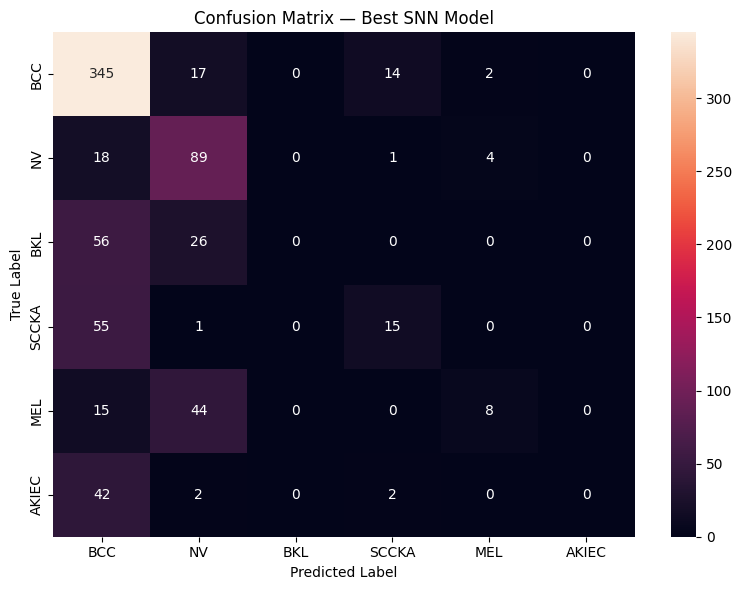


Predicted samples per class:
BCC: 531
NV: 179
BKL: 0
SCCKA: 32
MEL: 14
AKIEC: 0


In [ ]:
# Cell 8 — Evaluate best model on test set

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)
model.eval()

correct, total = 0, 0
all_predictions, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        spike_input = encode_batch(images)
        output_spikes = model(spike_input)
        predictions = output_spikes.sum(dim=0).argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)
        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = correct / total

print(f"Test Accuracy: {test_accuracy:.4f}")
print("\nClassification Report:\n")
print(classification_report(
    all_labels, all_predictions,
    labels=list(range(6)),
    target_names=[idx_to_label[i] for i in range(6)],
    zero_division=0
))

cm = confusion_matrix(all_labels, all_predictions, labels=list(range(6)))

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=[idx_to_label[i] for i in range(6)],
    yticklabels=[idx_to_label[i] for i in range(6)]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — Best SNN Model")
plt.tight_layout()
plt.show()

prediction_counts = Counter(all_predictions)

print("\nPredicted samples per class:")
for i in range(6):
    print(f"{idx_to_label[i]}: {prediction_counts.get(i, 0)}")

In [ ]:
#9
model.eval()
class_spike_sum = torch.zeros(6)
class_sample_count = torch.zeros(6)

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        spike_input = encode_batch(images)
        output_spikes = model(spike_input)

        spike_counts = output_spikes.sum(dim=(0, 2))

        for class_idx in range(6):
            mask = labels == class_idx
            if mask.any():
                class_spike_sum[class_idx] += spike_counts[mask].sum().cpu()
                class_sample_count[class_idx] += mask.sum().cpu()

avg_spikes = class_spike_sum / class_sample_count

print("Average output spike activity per true class:\n")

for i in range(6):
    print(f"{idx_to_label[i]}: {avg_spikes[i]:.4f}")

Average output spike activity per true class:

BCC: 41.0423
NV: 45.0446
BKL: 38.6829
SCCKA: 45.3099
MEL: 45.2388
AKIEC: 38.3913


In [ ]:
# Cell 10 — Class-wise output neuron spike analysis

model.eval()
class_spikes = {i: [] for i in range(6)}

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        spike_input = encode_batch(images)
        output_spikes = model(spike_input)

        spike_counts = output_spikes.sum(dim=0)

        for i in range(6):
            mask = labels == i
            if mask.any():
                class_spikes[i].append(spike_counts[mask].cpu())

print("Average output spikes for each true class:\n")

for true_class in range(6):
    if class_spikes[true_class]:
        values = torch.cat(class_spikes[true_class], dim=0)
        avg_values = values.mean(dim=0)

        print(f"{idx_to_label[true_class]}:")
        for pred_class in range(6):
            print(f"  {idx_to_label[pred_class]}: {avg_values[pred_class]:.4f}")
        print()

Average output spikes for each true class:

BCC:
  BCC: 27.6958
  NV: 1.7831
  BKL: 0.0000
  SCCKA: 10.1799
  MEL: 1.3836
  AKIEC: 0.0000

NV:
  BCC: 10.4196
  NV: 20.6964
  BKL: 0.0000
  SCCKA: 1.5893
  MEL: 12.3393
  AKIEC: 0.0000

BKL:
  BCC: 19.2317
  NV: 7.7195
  BKL: 0.0000
  SCCKA: 6.7073
  MEL: 5.0244
  AKIEC: 0.0000

SCCKA:
  BCC: 26.3099
  NV: 1.0423
  BKL: 0.0000
  SCCKA: 17.0563
  MEL: 0.9014
  AKIEC: 0.0000

MEL:
  BCC: 11.4925
  NV: 18.1940
  BKL: 0.0000
  SCCKA: 2.1493
  MEL: 13.4030
  AKIEC: 0.0000

AKIEC:
  BCC: 23.4565
  NV: 2.1304
  BKL: 0.0000
  SCCKA: 10.9348
  MEL: 1.8696
  AKIEC: 0.0000



In [ ]:
# Cell 1 — Initialize fresh SNN for rate encoding

model_rate = SpikingCNN(num_classes=6).to(device)

print("Fresh rate-encoding SNN model created.")
print("Threshold = 1.0")
print("Number of time steps =", num_steps)

Fresh rate-encoding SNN model created.
Threshold = 1.0
Number of time steps = 50


In [ ]:
# Cell 2 — Rate encoding function

def encode_batch_rate(images):
    return spikegen.rate(images, num_steps=num_steps)

print("Rate encoding function ready.")

Rate encoding function ready.


In [ ]:
optimizer_rate = optim.Adam(model_rate.parameters(), lr=1e-4)

In [ ]:
# Cell 3 — Optimizer and checkpoint setup

optimizer_rate = optim.Adam(model_rate.parameters(), lr=1e-4)

CHECKPOINT_DIR_RATE = f"{DRIVE_ROOT}/checkpoints_rate"
os.makedirs(CHECKPOINT_DIR_RATE, exist_ok=True)

best_model_path_rate = f"{CHECKPOINT_DIR_RATE}/best_model_rate.pth"
latest_checkpoint_path_rate = f"{CHECKPOINT_DIR_RATE}/latest_checkpoint_rate.pth"

start_epoch_rate = 0
best_val_acc_rate = 0.0

print("Optimizer:", "Adam")
print("Learning rate:", 1e-4)
print("Checkpoint folder:", CHECKPOINT_DIR_RATE)

Optimizer: Adam
Learning rate: 0.0001
Checkpoint folder: /content/drive/MyDrive/snn_project/checkpoints_rate
